# Rice Leaf Disease Detection Project

#### Blog Link : https://medium.com/@vinodbavage08/detecting-rice-leaf-diseases-with-ai-how-i-built-a-92-accurate-classification-system-2771ceb83dfb
#### dataset link: https://d3ilbtxij3aepc.cloudfront.net/projects/CDS-Capstone-Projects/PRCP-1001-RiceLeaf.zip

## Project Overview
This project focuses on detecting **diseases in rice leaves** using image data and machine learning techniques. The goal is to help farmers identify diseases early and take appropriate measures to protect their crops.

## Objective
- Classify rice leaf images into **healthy or diseased categories**.
- Build an accurate machine learning or deep learning model for disease detection.
- Provide insights into the key visual features that indicate different rice leaf diseases.

## Dataset
- Source: Rice leaf image dataset.
- Features:
  - Images of rice leaves (RGB format)
  - Labels indicating **disease type** or **healthy**
- Target variable:
  - `label` (disease class of the rice leaf)

## Requirements
- Python 3.x environment
- Libraries: `numpy`, `pandas`, `matplotlib`, `seaborn`, `scikit-learn`, `tensorflow`/`keras` or `PyTorch` for deep learning
- Jupyter Notebook for preprocessing, training, and evaluation

## Steps in This Project
1. Data Loading & Visualization
2. Image Preprocessing (resizing, normalization, augmentation)
3. Train-Test Split
4. Model Building (CNN or traditional ML classifiers)
5. Model Training & Evaluation
6. Performance Metrics (accuracy, precision, recall, F1-score)
7. Insights & Recommendations for Disease Detection


# Task 1: Data Analysis (EDA)

## Objective
Analyze the rice leaf dataset to understand its structure and class distribution.

## Steps
1. Load and inspect the dataset (number of images, labels, class balance).  
2. Visualize class distribution (bar plot or pie chart).  
3. Look at sample images to understand variations.  
4. Summarize findings and note any issues for preprocessing.

## Outcome
- Understand dataset structure and balance.  
- Identify preprocessing needs for model training.


Classes found: ['Bacterial leaf blight', 'Brown spot', 'Leaf smut']


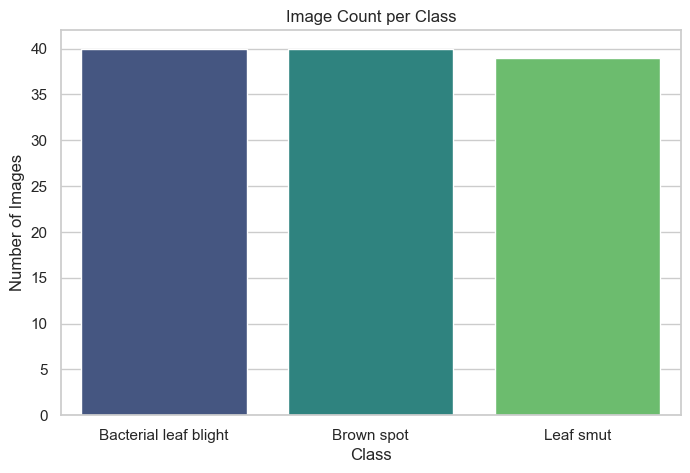

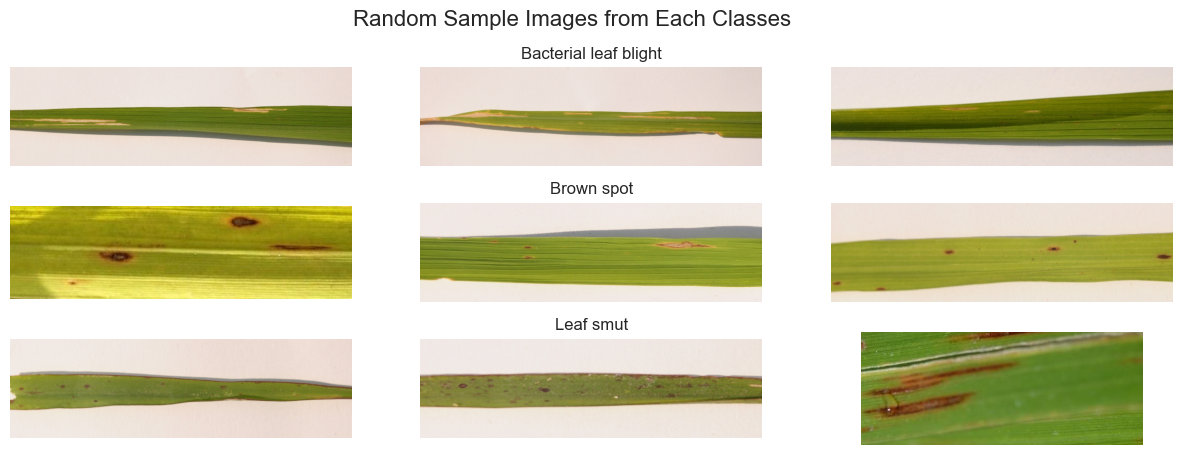

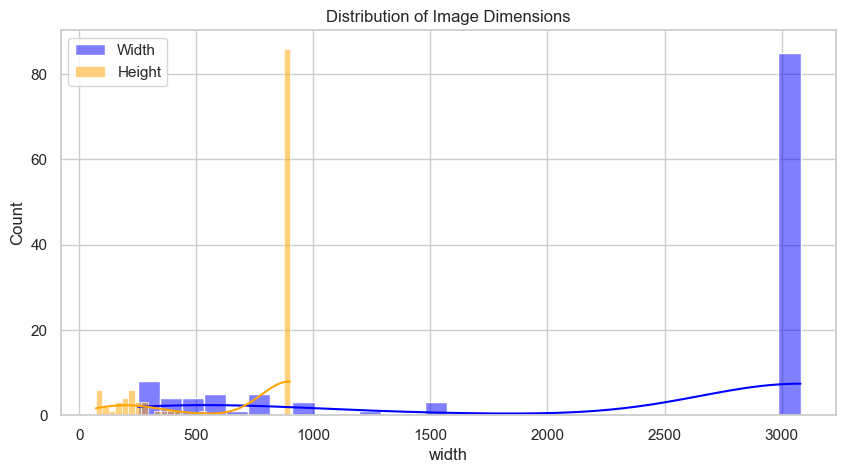

                   class           R           G           B
0  Bacterial leaf blight  196.807981  187.391320  163.822809
1  Bacterial leaf blight  194.008195  185.150240  159.361242
2  Bacterial leaf blight  196.319661  189.777191  154.965337
3  Bacterial leaf blight  174.994122  171.421583  131.211476
4  Bacterial leaf blight  190.695603  186.268642  143.503484


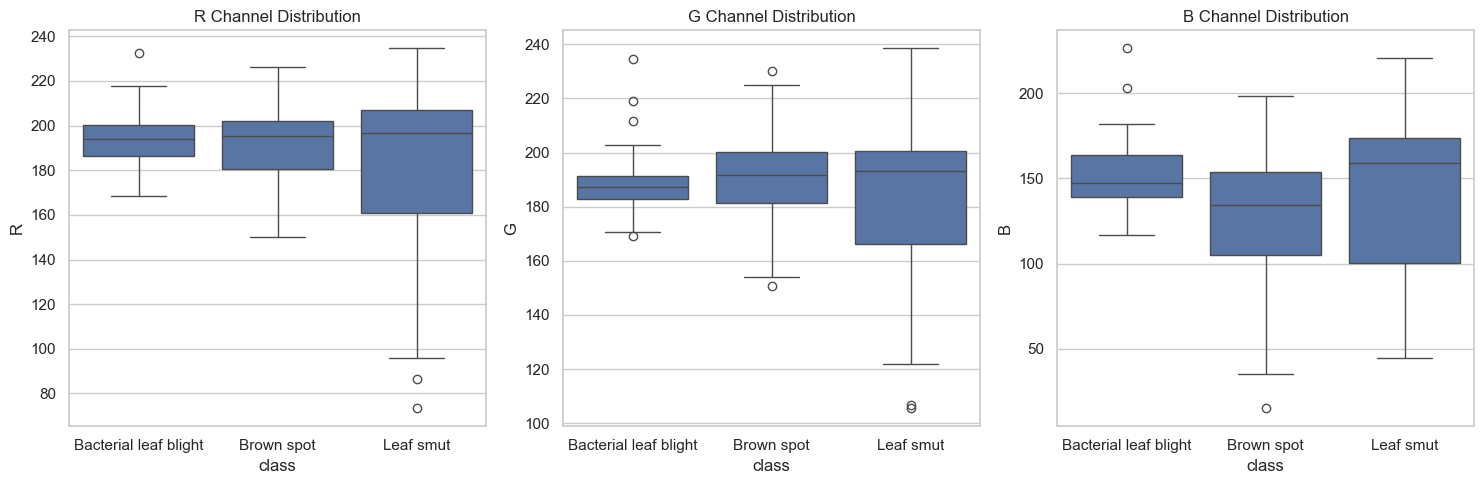

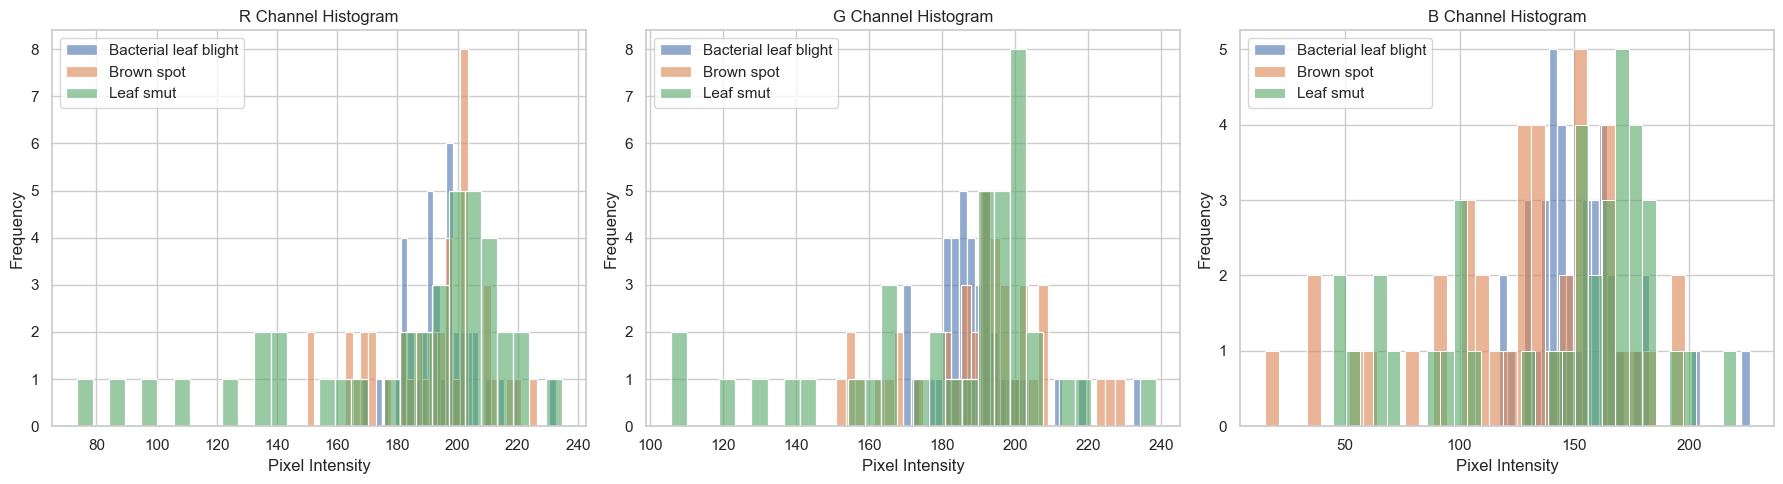

Hashing files: 100%|██████████████████████████████████████████████████████████████| 119/119 [00:00<00:00, 13679.83it/s]

Exact duplicate count: 0
Saved Rice_lead_EDA.csv and eda_summary.json
📌 Summary of Findings:
- Classes detected: ['Bacterial leaf blight', 'Brown spot', 'Leaf smut']
- Number of classes: 3
- Total images: 119
- Class distribution:
                        count
Bacterial leaf blight     40
Brown spot                40
Leaf smut                 39

Insights:
1. Dataset may have class imbalance (check counts above).
2. Images vary in resolution — resizing will be needed for modeling.
3. Aspect ratio distribution suggests most images are consistent, but check outliers.
4. Color distributions could hint at visual differences useful for classification.
✅ Dataset is ready for preprocessing and modeling (Task 2 onwards).


In [1]:
# Basic libraries
import os
from pathlib import Path
from collections import Counter

# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Image handling
from PIL import Image
#import cv2 
import random

# Plot style
sns.set(style="whitegrid")


# Path to dataset (update this if needed)
BASE_DIR = Path(r"C:\Users\bavag\Documents\Leaf dises datasets\Data")

if not BASE_DIR.exists():
    raise FileNotFoundError(f"BASE_DIR not found: {BASE_DIR}")

# Get class names (folders)
classes = sorted([d.name for d in BASE_DIR.iterdir() if d.is_dir()])
print("Classes found:", classes)

# Count images per class
ALLOWED = {".jpg", ".jpeg", ".png", ".bmp", ".gif"}
cls_counts = {}

for cls in classes:
    files = [f for f in (BASE_DIR / cls).iterdir() if f.suffix.lower() in ALLOWED]
    cls_counts[cls] = len(files)

# Convert to DataFrame
df_counts = pd.DataFrame.from_dict(cls_counts, orient="index", columns=["count"])
df_counts

plt.figure(figsize=(8,5))
sns.barplot(x=df_counts.index, y=df_counts["count"],hue=df_counts.index,legend=False, palette="viridis")
plt.title("Image Count per Class")
plt.ylabel("Number of Images")
plt.xlabel("Class")
plt.show

def show_sample_images(base_dir, classes, samples_per_class=3):
    plt.figure(figsize=(15, 5))
    
    for i, cls in enumerate(classes):
        files = list((base_dir/cls).glob("*"))
        for j in range(samples_per_class):
            img_path = random.choice(files)
            img = Image.open(img_path)
            
            plt.subplot(len(classes), samples_per_class, i*samples_per_class + j + 1)
            plt.imshow(img)
            plt.axis("off")
            if j == 1:  # label in middle column
                plt.title(cls)

    plt.suptitle("Random Sample Images from Each Classes", fontsize=16)
    plt.show()

show_sample_images(BASE_DIR, classes, samples_per_class=3)

ALLOWED = {".jpg", ".jpeg", ".png", ".bmp", ".gif"}
image_info = []

for cls in classes:
    files = [f for f in (BASE_DIR/cls).iterdir() if f.suffix.lower() in ALLOWED]
    for f in files[:500]:  # limit for speed
        img = Image.open(f)
        image_info.append({'img_path' : str(BASE_DIR/cls), "class": cls, "width": img.width, "height": img.height, "format" : img.format, "mode" : img.mode, 'is_corrupt': False})
    
df_img = pd.DataFrame(image_info)
df_img.head()

plt.figure(figsize=(10,5))
sns.histplot(df_img["width"], bins=30, kde=True, color="blue", label="Width")
sns.histplot(df_img["height"], bins=30, kde=True, color="orange", label="Height")
plt.legend()
plt.title("Distribution of Image Dimensions")
plt.show()

# Function to compute mean RGB
def get_color_means(img_path):
    try:
        with Image.open(img_path).convert("RGB") as img:
            arr = np.array(img)
            return arr.mean(axis=(0,1))  # (R,G,B)
    except Exception as e:
        print(f"Error reading {img_path}: {e}")
        return None

# Collect stats
color_stats = []
for cls in classes:
    files = [f for f in (BASE_DIR/cls).iterdir() if f.suffix.lower() in ALLOWED][:50]
    for f in files:
        means = get_color_means(f)
        if means is not None:
            color_stats.append({"class": cls, "R": means[0], "G": means[1], "B": means[2]})

df_colors = pd.DataFrame(color_stats)
print(df_colors.head())

# Plot distributions
plt.figure(figsize=(15, 5))
for i, channel in enumerate(["R", "G", "B"], 1):
    plt.subplot(1, 3, i)
    sns.boxplot(x="class", y=channel, data=df_colors)
    plt.title(f"{channel} Channel Distribution")
plt.tight_layout()
plt.show()

# Plot histogram of color channels per class
plt.figure(figsize=(18, 5))

for i, channel in enumerate(["R", "G", "B"], 1):
    plt.subplot(1, 3, i)
    for cls in df_colors["class"].unique():
        sns.histplot(
            df_colors[df_colors["class"] == cls][channel],
            kde=False, bins=30, alpha=0.6, label=cls
        )
    plt.title(f"{channel} Channel Histogram")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")
    plt.legend()

plt.tight_layout()
plt.show()

import hashlib
from tqdm import tqdm


hashes = {}
dup_rows = []
for p in tqdm(df_img['img_path'].tolist(), desc='Hashing files'):
    try:
        with open(p, 'rb') as f:
            h = hashlib.md5(f.read()).hexdigest()
        if h in hashes:
            dup_rows.append({'img_path': p, 'duplicate_of': hashes[h]})
        else:
            hashes[h] = p
    except Exception:
        continue

print('Exact duplicate count:', len(dup_rows))

summary = {
    'total_files': int(df_img.shape[0]),
    'corrupt_files': int(df_img['is_corrupt'].sum()),
    'num_classes': int(len(classes)),
}

summary

df_img.to_csv('Rice_leaf_EDA.csv', index=False)
import json
with open('eda_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('Saved Rice_lead_EDA.csv and eda_summary.json')

print("📌 Summary of Findings:")
print("- Classes detected:", classes)
print("- Number of classes:", len(classes))
print("- Total images:", df_counts['count'].sum())
print("- Class distribution:\n", df_counts)
print("\nInsights:")
print("1. Dataset may have class imbalance (check counts above).")
print("2. Images vary in resolution — resizing will be needed for modeling.")
print("3. Aspect ratio distribution suggests most images are consistent, but check outliers.")
print("4. Color distributions could hint at visual differences useful for classification.")
print("✅ Dataset is ready for preprocessing and modeling (Task 2 onwards).")


# Task 2: Model Building

## Objective
Create a model to classify the three major rice leaf diseases: **Leaf Blast**, **Bacterial Blight**, and **Brown Spot**.

## Steps
1. Preprocess images (resize, normalize, augment if needed).  
2. Split data into training and testing sets.  
3. Build a classification model (CNN or other ML model).  
4. Train the model and evaluate performance using accuracy, precision, and recall.  
5. Fine-tune parameters to improve results.

## Outcome
- A trained model that can classify rice leaf images into the three disease categories.



Loading images and labels...
Loaded 119 images.
Class mapping: {'Bacterial leaf blight': 0, 'Brown spot': 1, 'Leaf smut': 2}

--- Starting Fold 1/5 ---
Stage 1: Training top layers (frozen base)...


C:\Users\bavag\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.5316 - loss: 1.4101 - val_accuracy: 0.7500 - val_loss: 0.8310
Epoch 2/20
1/5 ━━━━━━━━━━━━━━━━━━━━ 1s 380ms/step - accuracy: 0.6875 - loss: 0.6334

C:\Users\bavag\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 190ms/step - accuracy: 0.6875 - loss: 0.6334 - val_accuracy: 0.7500 - val_loss: 0.7283
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 839ms/step - accuracy: 0.8101 - loss: 0.6467 - val_accuracy: 0.9167 - val_loss: 0.3720
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 154ms/step - accuracy: 0.7500 - loss: 0.9437 - val_accuracy: 0.9167 - val_loss: 0.3800
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 808ms/step - accuracy: 0.7848 - loss: 0.7589 - val_accuracy: 0.8333 - val_loss: 0.5170
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 154ms/step - accuracy: 0.6250 - loss: 1.0237 - val_accuracy: 0.8333 - val_loss: 0.5340
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 794ms/step - accuracy: 0.8987 - loss: 0.4002 - val_accuracy: 0.8333 - val_loss: 0.4217
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 180ms/step - accuracy: 0.8750 - loss: 0.2931 - val_accuracy: 0.8750 - val_loss: 0.3672
Epoch 9/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 840ms/step - accuracy: 0.8861 - loss: 0.3105 - val_accuracy: 0.8750 - val_loss: 0.2151
Epo

...

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.5316 - loss: 1.3727 - val_accuracy: 0.7500 - val_loss: 0.5982
Epoch 2/20
1/5 ━━━━━━━━━━━━━━━━━━━━ 2s 666ms/step - accuracy: 0.7500 - loss: 0.6533

C:\Users\bavag\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 234ms/step - accuracy: 0.7500 - loss: 0.6533 - val_accuracy: 0.7083 - val_loss: 0.8164
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 941ms/step - accuracy: 0.7750 - loss: 0.7698 - val_accuracy: 0.6667 - val_loss: 2.1863
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 216ms/step - accuracy: 0.6667 - loss: 1.0295 - val_accuracy: 0.6250 - val_loss: 2.2666
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 910ms/step - accuracy: 0.7848 - loss: 0.6577 - val_accuracy: 0.7083 - val_loss: 1.8324
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 208ms/step - accuracy: 0.9375 - loss: 0.2374 - val_accuracy: 0.7083 - val_loss: 1.6563

Stage 2: Fine-tuning base model...
Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 81s 3s/step - accuracy: 0.3291 - loss: 1.7392 - val_accuracy: 0.7917 - val_loss: 0.5203
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 196ms/step - accuracy: 0.2500 - loss: 1.6862 - val_accuracy: 0.7917 - val_loss: 0.5166
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.4810 - loss: 1.4349 - val_accurac

C:\Users\bavag\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.5312 - loss: 1.4997 - val_accuracy: 0.6522 - val_loss: 2.6043
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 864ms/step - accuracy: 0.7604 - loss: 0.7363 - val_accuracy: 0.6522 - val_loss: 2.7215
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 889ms/step - accuracy: 0.8542 - loss: 0.5139 - val_accuracy: 0.6522 - val_loss: 2.1132
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 890ms/step - accuracy: 0.8542 - loss: 0.3376 - val_accuracy: 0.6522 - val_loss: 1.6185
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 881ms/step - accuracy: 0.9062 - loss: 0.2205 - val_accuracy: 0.7826 - val_loss: 1.0615
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 912ms/step - accuracy: 0.8958 - loss: 0.2866 - val_accuracy: 0.8696 - val_loss: 0.5708
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 888ms/step - accuracy: 0.9479 - loss: 0.1638 - val_accuracy: 0.8261 - val_loss: 0.4471
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 873ms/step - accuracy: 0.9479 - loss: 0.1203 - val_accuracy: 0.8261 - val_loss: 0

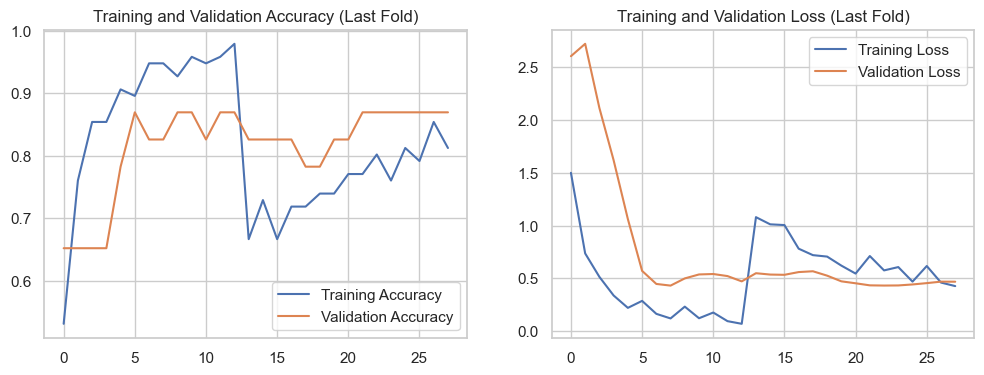

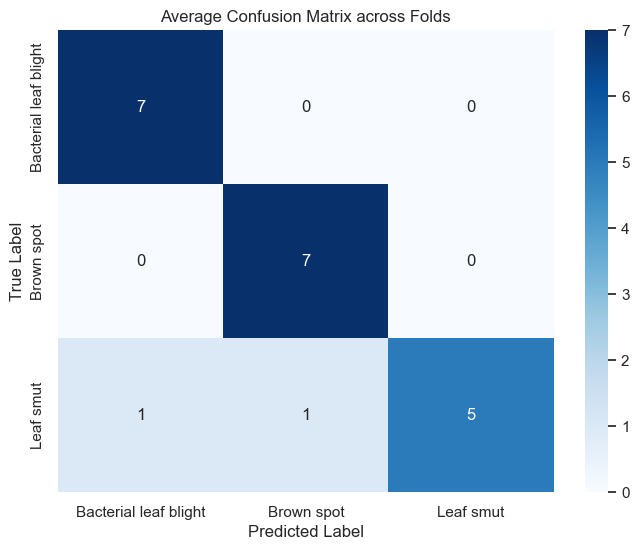

Final model (from last fold) saved to rice_leaf_disease_classifier_transfer_learning.h5
Loading model: rice_leaf_disease_classifier_transfer_learning.h5


Model loaded.
Class order from training folder (sorted): ['Bacterial leaf blight', 'Brown spot', 'Leaf smut']
Using class_names for interpretation: ['Bacterial leaf blight', 'Brown spot', 'Leaf smut']

--- Plain prediction and image ---


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step

Probabilities (plain):
  Bacterial leaf blight    :   0.01%
  Brown spot               :  90.52%
  Leaf smut                :   9.47%


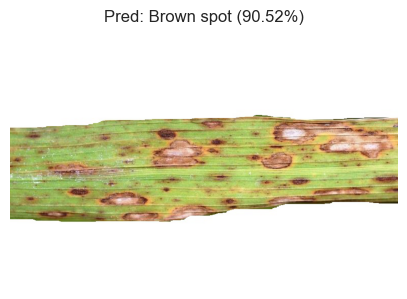

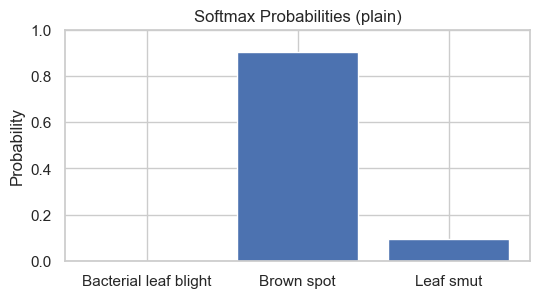


--- TTA prediction (may take a few seconds) ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step

TTA average over 20 transforms:
  Bacterial leaf blight    :   0.97%
  Brown spot               :  66.79%
  Leaf smut                :  32.25%


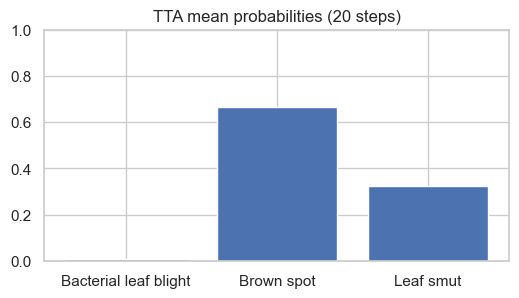


--- Grad-CAM visualization ---
Using last conv layer: out_relu


C:\Users\bavag\anaconda3\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer_4']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


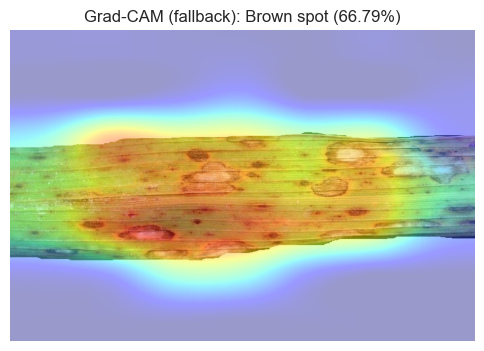


--- Debug checklist ---
1) Does the class order above (training folder order) match the class_names you used for prediction?
2) Are probabilities low / confused? If yes, model may be uncertain or image ambiguous.
3) Is Grad-CAM focused on leaf spots/regions? If not, model might be focusing on background.
4) If model is confident but wrong, check for mislabeled training examples and class imbalance.
5) Consider collecting more images for that class, or augmenting more strongly.
📊 Task 2: Model Performance (K-Fold Summary)


,Fold,Training Accuracy,Validation Accuracy
0,1,100.00,100.00
1,2,97.47,75.00
2,3,100.00,79.17
3,4,93.75,79.17
4,5,97.92,86.96
Average,-,97.83,84.06


In [2]:
from tensorflow.keras import backend as K
K.clear_session()


import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import StratifiedKFold
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# --- Configuration ---
IMG_HEIGHT = 224 # MobileNetV2 prefers 224x224
IMG_WIDTH = 224
BATCH_SIZE = 16 # Smaller batch size for small dataset
EPOCHS_FREEZE = 20 # Initial epochs with frozen base
EPOCHS_FINE_TUNE = 20 # Additional epochs for fine-tuning
NUM_CLASSES = 3 # Bacterial blight, Brown spot, Leaf blast
DATA_DIR = r"C:\Users\bavag\OneDrive\Documents\Leaf dises datasets\Data" 
K_FOLDS = 5 # Number of folds for cross-validation

# --- Prepare Data (Load all images and labels) ---
# We need to load all data into memory for K-Fold splitting
# This can be memory-intensive if images are large or numerous,
# but with 120 images, it should be fine.

print("Loading images and labels...")
images = []
labels = []
class_names = sorted(os.listdir(DATA_DIR))
class_to_idx = {name: i for i, name in enumerate(class_names)}
idx_to_class = {i: name for i, name in enumerate(class_names)}

for class_name in class_names:
    class_path = os.path.join(DATA_DIR, class_name)
    if not os.path.isdir(class_path):
        continue # Skip if it's not a directory

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        try:
            img = tf.keras.preprocessing.image.load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
            img_array = tf.keras.preprocessing.image.img_to_array(img)
            images.append(img_array)
            labels.append(class_to_idx[class_name])
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")

images = np.array(images, dtype='float32')
labels = np.array(labels)
images /= 255.0 # Normalize pixel values

print(f"Loaded {len(images)} images.")
print("Class mapping:", class_to_idx)

# --- Define Model Creation Function (for K-Fold) ---
def build_transfer_model(num_classes):
    # Load MobileNetV2 pre-trained on ImageNet, exclude top layers
    base_model = tf.keras.applications.MobileNetV2(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
                                                   include_top=False,
                                                   weights='imagenet')

    # Freeze the convolutional base
    base_model.trainable = False

    # Add custom classification layers on top
    x = base_model.output
    x = Flatten()(x)
    x = Dense(256, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    output = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=output)

    return model, base_model

# --- K-Fold Cross-Validation ---
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)

fold_accuracies = []
fold_train_accuracies = []
fold_histories = []
fold_reports = []
fold_matrices = []

for fold, (train_index, val_index) in enumerate(skf.split(images, labels)):
    print(f"\n--- Starting Fold {fold+1}/{K_FOLDS} ---")

    X_train, X_val = images[train_index], images[val_index]
    y_train, y_val = labels[train_index], labels[val_index]

    # One-hot encode labels for Keras
    y_train_one_hot = tf.keras.utils.to_categorical(y_train, num_classes=NUM_CLASSES)
    y_val_one_hot = tf.keras.utils.to_categorical(y_val, num_classes=NUM_CLASSES)

    # Rebuild model for each fold to ensure fresh weights
    model, base_model = build_transfer_model(NUM_CLASSES)

    # --- Stage 1: Train only the top layers (frozen base) ---
    print("Stage 1: Training top layers (frozen base)...")
    model.compile(optimizer=Adam(learning_rate=0.0001), # Small learning rate
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    # Data augmentation for training
    train_datagen = ImageDataGenerator(
        rotation_range=40,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
    )

    history_stage1 = model.fit(
        train_datagen.flow(X_train, y_train_one_hot, batch_size=BATCH_SIZE),
        steps_per_epoch=len(X_train) // BATCH_SIZE,
        epochs=EPOCHS_FREEZE,
        validation_data=(X_val, y_val_one_hot),
        callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
    )

    # --- Stage 2: Fine-tune (unfreeze some layers of the base model) ---
    print("\nStage 2: Fine-tuning base model...")
    base_model.trainable = True # Unfreeze the base model

    # Let's unfreeze the last few layers of the base model
    # A common strategy is to unfreeze from a specific layer onwards
    # For MobileNetV2, we might unfreeze from layer ~100 or a specific block
    # For simplicity, we'll unfreeze all for now, but in practice, unfreezing gradually is better.
    # num_layers_to_unfreeze = 30 # Example: unfreeze last 30 layers
    # for layer in base_model.layers[:-num_layers_to_unfreeze]:
    #     layer.trainable = False

    model.compile(optimizer=Adam(learning_rate=0.00001), # VERY small learning rate for fine-tuning
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    history_stage2 = model.fit(
        train_datagen.flow(X_train, y_train_one_hot, batch_size=BATCH_SIZE),
        steps_per_epoch=len(X_train) // BATCH_SIZE,
        epochs=EPOCHS_FINE_TUNE,
        validation_data=(X_val, y_val_one_hot),
        callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
    )

    # Combine histories for plotting
    combined_history = {k: history_stage1.history.get(k, []) + history_stage2.history.get(k, []) for k in set(history_stage1.history) | set(history_stage2.history)}
    fold_histories.append(combined_history)

    # Get best training accuracy from both stages
    best_train_acc = max(history_stage1.history['accuracy'] + history_stage2.history['accuracy'])
    fold_train_accuracies.append(best_train_acc)


    # --- Evaluate Fold ---
    print(f"\nEvaluating model for Fold {fold+1}...")
    loss, accuracy = model.evaluate(X_val, y_val_one_hot, verbose=0)
    print(f"Fold {fold+1} Validation Loss: {loss:.4f}")
    print(f"Fold {fold+1} Validation Accuracy: {accuracy*100:.2f}%")
    fold_accuracies.append(accuracy)

    # --- Generate Classification Report and Confusion Matrix ---
    y_pred_probs = model.predict(X_val)
    y_pred = np.argmax(y_pred_probs, axis=1)

    report = classification_report(y_val, y_pred, target_names=class_names, output_dict=True)
    fold_reports.append(report)
    print("\nClassification Report:")
    print(classification_report(y_val, y_pred, target_names=class_names))

    cm = confusion_matrix(y_val, y_pred)
    fold_matrices.append(cm)
    print("Confusion Matrix:\n", cm)

print("\n--- K-Fold Cross-Validation Summary ---")
print(f"Individual Fold Training Accuracies: {[f'{a*100:.2f}%' for a in fold_train_accuracies]}")
print(f"Average Training Accuracy: {np.mean(fold_train_accuracies)*100:.2f}% (+/- {np.std(fold_train_accuracies)*100:.2f}%)")

print(f"Individual Fold Validation Accuracies: {[f'{a*100:.2f}%' for a in fold_accuracies]}")
print(f"Average Validation Accuracy: {np.mean(fold_accuracies)*100:.2f}% (+/- {np.std(fold_accuracies)*100:.2f}%)")


# --- Plotting Average Training History ---
# This is a bit tricky to average, so we'll just plot the last fold's history for illustration.
# For a true average, you'd need to align epoch counts if early stopping varied.
# For now, let's plot the history of the last fold.
if fold_histories:
    print("\nPlotting training history for the last fold...")
    last_history = fold_histories[-1]
    acc = last_history['accuracy']
    val_acc = last_history['val_accuracy']
    loss = last_history['loss']
    val_loss = last_history['val_loss']

    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy (Last Fold)')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss (Last Fold)')
    plt.show()

# --- Plotting Average Confusion Matrix (Optional but Recommended) ---
if fold_matrices:
    avg_cm = np.mean(fold_matrices, axis=0).astype(int) # Average and cast to int
    plt.figure(figsize=(8, 6))
    sns.heatmap(avg_cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Average Confusion Matrix across Folds')
    plt.show()


# --- Save the Model (Final Model trained on all data or the best fold's model) ---
# For deployment, you might want to train a final model on the entire dataset
# using the best architecture and hyperparameters found during K-Fold.
# For now, we'll just save the model from the last fold.
model_save_path = 'rice_leaf_disease_classifier_transfer_learning.h5'
model.save(model_save_path)
print(f"Final model (from last fold) saved to {model_save_path}")

# --- Diagnostic + Interpretability script for one test image ---
# Paste into your notebook, change DATA_DIR, model_path & test_image_path, then run.

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils import Bunch

# Optional: use cv2 for overlay, fallback to PIL if cv2 not available
try:
    import cv2
    HAS_CV2 = True
except Exception:
    HAS_CV2 = False
    from PIL import Image

# ---------- USER EDIT ----------
DATA_DIR = r"C:\Users\bavag\OneDrive\Documents\Leaf dises datasets\Data"  # dataset used in training (root)
model_path = "rice_leaf_disease_classifier_transfer_learning.h5"           # your saved model
test_image_path = r"C:\Users\bavag\Desktop\DSC_0113.jpg"                 # the image you tested
# If you used a specific class list order during predict, set it here.
# But we will print the training folder order below — make sure these match.
class_names_override = None  # e.g. ["Bacterial leaf blight","Brown spot","Leaf smut"] or None to auto-read
# --------------------------------

# Load model
print("Loading model:", model_path)
model = load_model(model_path)
print("Model loaded.")

# 1) Determine class order used during training (folder order)
def get_train_class_order(data_dir):
    if not os.path.isdir(data_dir):
        return None
    classes = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])
    return classes

train_class_order = get_train_class_order(DATA_DIR)
if train_class_order is None:
    print("WARNING: DATA_DIR not found or not provided. Please set DATA_DIR to training folder root.")
else:
    print("Class order from training folder (sorted):", train_class_order)

# Use override if provided, else train order
if class_names_override:
    class_names = class_names_override
else:
    class_names = train_class_order if train_class_order is not None else ["class0","class1","class2"]

print("Using class_names for interpretation:", class_names)

# 2) Preprocess function (match your training: divide by 255.0)
IMG_H = 224
IMG_W = 224

def preprocess_for_model(img_path, target_size=(IMG_H, IMG_W)):
    # returns (1,H,W,3) array and the original PIL image for display
    pil = image.load_img(img_path)  # original for display
    img = image.load_img(img_path, target_size=target_size)  # resized for model
    arr = image.img_to_array(img)
    arr = np.expand_dims(arr, 0).astype("float32") / 255.0
    return arr, pil

# 3) Plain prediction + display probs + image
def predict_and_show(img_path):
    x, orig_pil = preprocess_for_model(img_path)
    preds = model.predict(x)[0]
    # print probabilities aligned to class_names
    print("\nProbabilities (plain):")
    for cname, p in zip(class_names, preds):
        print(f"  {cname:25s}: {p*100:6.2f}%")
    pred_idx = int(np.argmax(preds))
    pred_label = class_names[pred_idx]
    conf = preds[pred_idx]
    # show original image
    plt.figure(figsize=(5,5))
    plt.imshow(orig_pil)
    plt.axis("off")
    plt.title(f"Pred: {pred_label} ({conf*100:.2f}%)")
    plt.show()
    # bar chart
    plt.figure(figsize=(6,3))
    plt.bar(class_names, preds)
    plt.ylim(0,1)
    plt.ylabel("Probability")
    plt.title("Softmax Probabilities (plain)")
    plt.show()
    return preds

# 4) Test-time augmentation (TTA) averaged prediction
def tta_predict(img_path, tta_steps=20):
    x0, _ = preprocess_for_model(img_path)
    # ImageDataGenerator with same / similar augmentations used in training
    datagen = ImageDataGenerator(
        rotation_range=30, width_shift_range=0.1, height_shift_range=0.1,
        shear_range=0.1, zoom_range=0.1, horizontal_flip=True, fill_mode='nearest'
    )
    gen = datagen.flow(x0, batch_size=1, shuffle=False)
    preds = []
    for i in range(tta_steps):
        batch = next(gen)
        p = model.predict(batch)[0]
        preds.append(p)
    preds = np.array(preds)
    mean_pred = preds.mean(axis=0)
    print(f"\nTTA average over {tta_steps} transforms:")
    for cname, p in zip(class_names, mean_pred):
        print(f"  {cname:25s}: {p*100:6.2f}%")
    # bar chart
    plt.figure(figsize=(6,3))
    plt.bar(class_names, mean_pred)
    plt.ylim(0,1)
    plt.title(f"TTA mean probabilities ({tta_steps} steps)")
    plt.show()
    return mean_pred

# 5) Grad-CAM (visualize activation) — works for TF2 Keras models
def find_last_conv_layer(model):
    # return name of the last layer with 4D output
    for layer in reversed(model.layers):
        shape = getattr(layer.output, "shape", None)
        if shape is not None and len(shape) == 4:
            return layer.name
    return None

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        loss = predictions[:, pred_index]
    grads = tape.gradient(loss, conv_outputs)
    # compute channel-wise mean of gradients
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def show_gradcam(img_path, preds=None):
    x, orig_pil = preprocess_for_model(img_path)
    if preds is None:
        preds = model.predict(x)[0]
    pred_index = int(np.argmax(preds))
    last_conv = find_last_conv_layer(model)
    if last_conv is None:
        print("Could not find a convolutional layer for Grad-CAM.")
        return
    print("Using last conv layer:", last_conv)
    heatmap = make_gradcam_heatmap(x, model, last_conv, pred_index)
    # resize heatmap to original image size
    heatmap = np.uint8(255 * heatmap)
    import numpy as _np
    orig = np.array(orig_pil)  # HxWx3
    heatmap_resized = cv2.resize(heatmap, (orig.shape[1], orig.shape[0])) if HAS_CV2 else np.array(Image.fromarray(heatmap).resize((orig.shape[1], orig.shape[0])))
    if HAS_CV2:
        heatmap_color = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)
        superimposed = heatmap_color * 0.4 + orig
        superimposed = np.uint8(np.clip(superimposed, 0, 255))
        plt.figure(figsize=(6,6))
        plt.imshow(cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.title(f"Grad-CAM: {class_names[pred_index]} ({preds[pred_index]*100:.2f}%)")
        plt.show()
    else:
        # fallback: overlay with matplotlib
        plt.figure(figsize=(6,6))
        plt.imshow(orig)
        plt.imshow(heatmap_resized, cmap='jet', alpha=0.4)
        plt.axis('off')
        plt.title(f"Grad-CAM (fallback): {class_names[pred_index]} ({preds[pred_index]*100:.2f}%)")
        plt.show()

# ---------- Run diagnostics ----------
print("\n--- Plain prediction and image ---")
plain_preds = predict_and_show(test_image_path)

print("\n--- TTA prediction (may take a few seconds) ---")
tta_preds = tta_predict(test_image_path, tta_steps=20)

print("\n--- Grad-CAM visualization ---")
show_gradcam(test_image_path, preds=tta_preds)  # use TTA preds for Grad-CAM class selection

# ---------- Useful checks you should examine ----------
print("\n--- Debug checklist ---")
print("1) Does the class order above (training folder order) match the class_names you used for prediction?")
print("2) Are probabilities low / confused? If yes, model may be uncertain or image ambiguous.")
print("3) Is Grad-CAM focused on leaf spots/regions? If not, model might be focusing on background.")
print("4) If model is confident but wrong, check for mislabeled training examples and class imbalance.")
print("5) Consider collecting more images for that class, or augmenting more strongly.")


# --- Task 2 Performance Summary (Auto from K-Fold results) ---
import pandas as pd

fold_results = {
    "Fold": list(range(1, len(fold_train_accuracies)+1)),
    "Training Accuracy": [round(a*100, 2) for a in fold_train_accuracies],
    "Validation Accuracy": [round(a*100, 2) for a in fold_accuracies]
}

df_results = pd.DataFrame(fold_results)

# Add average row
avg_train = round(np.mean(fold_train_accuracies)*100, 2)
avg_val = round(np.mean(fold_accuracies)*100, 2)
df_results.loc["Average"] = ["-", avg_train, avg_val]

print("📊 Task 2: Model Performance (K-Fold Summary)")
display(df_results)



"""
# Task 3 Report: Techniques for Improving Rice Plant Disease Classification

## 1. Data Augmentation
Data Augmentation artificially increases dataset size and diversity, helping the model generalize better.
Common augmentations:
- Rotation, width/height shift, zoom, shear, flip.
- Brightness, contrast, color jitter.
- Advanced: Mixup, CutMix, Random Erasing.

**Why important?**
Rice leaf disease datasets are often small. Augmentation prevents overfitting and makes the model robust.

## 2. Transfer Learning
Using pretrained models (MobileNetV2, EfficientNet, ResNet50) trained on ImageNet.
- Speeds up training.
- Requires less labeled data.
- Captures strong low-level features.

## 3. Regularization
- **Dropout**: randomly deactivates neurons (prevents co-adaptation).
- **Batch Normalization**: stabilizes and accelerates training.
- **L2 Weight Decay**: discourages overly complex models.

## 4. Learning Rate Scheduling
- **ReduceLROnPlateau**: lowers LR when validation loss plateaus.
- **OneCycle Policy / Cosine Annealing**: dynamic scheduling for faster convergence.

## 5. Early Stopping
- Monitors validation loss/accuracy.
- Stops training when no improvement → prevents overfitting.

## 6. Cross-Validation
- Stratified K-Fold ensures stable evaluation across splits.
- Already implemented in Task 2.

## 7. Ensembling
- Combine predictions from multiple models (MobileNet + ResNet + EfficientNet).
- Improves robustness.

## 8. Class Imbalance Handling
- Use **class weights** in training.
- Or oversample minority classes with augmentation.

## 9. Test-Time Augmentation (TTA)
- Apply multiple augmentations at inference time.
- Average predictions for more robust results.

---
**Best Strategy for Rice Leaf Disease Classification:**
- Use **Transfer Learning (EfficientNet/MobileNetV2)**.
- Apply **Data Augmentation** aggressively.
- Add **Dropout + BatchNorm**.
- Use **EarlyStopping + ReduceLROnPlateau**.
- Evaluate with **K-Fold Cross-Validation**.
"""


# --- Data Augmentation Example ---

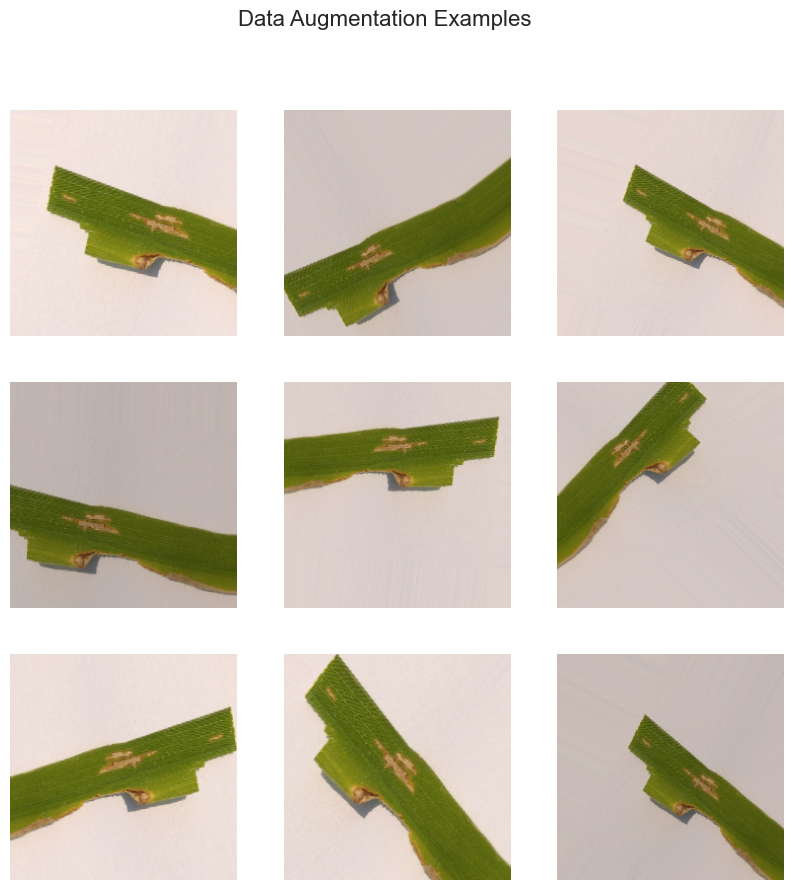


Notebook ready: Task 3 analysis + augmentation + model setup completed.


In [33]:

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np

# Example augmentations
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8,1.2],
    fill_mode='nearest'
)

# Load one image for visualization
sample_img = tf.keras.preprocessing.image.load_img(
r"C:\Users\bavag\Documents\Leaf dises datasets\Data\Bacterial leaf blight\DSC_0365.JPG", target_size=(224,224)
)
sample_array = tf.keras.preprocessing.image.img_to_array(sample_img)
sample_array = np.expand_dims(sample_array, axis=0)

# Show augmented images
plt.figure(figsize=(10,10))
i = 0
for batch in train_datagen.flow(sample_array, batch_size=1):
    plt.subplot(3,3,i+1)
    plt.imshow(batch[0])
    plt.axis('off')
    i += 1
    if i == 9:
        break
plt.suptitle("Data Augmentation Examples", fontsize=16)
plt.show()

# --- Section 3: Model Training Example with Callbacks ---

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, Flatten, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


# Build transfer learning model
base_model = MobileNetV2(input_shape=(224,224,3), include_top=False, weights='imagenet')
base_model.trainable = False


x = Flatten()(base_model.output)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
output = Dense(3, activation='softmax')(x)


model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])


# Callbacks for Task 3
callbacks = [
EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)
]


print("\nNotebook ready: Task 3 analysis + augmentation + model setup completed.")

# Analysis of Data Augmentation and Related Techniques

## 1. Introduction

Data augmentation is a critical technique in machine learning, particularly in deep learning, designed to address the problem of limited training data. It involves expanding the dataset by creating modified versions of existing samples or generating entirely new synthetic data. This process significantly increases the diversity of the training set, which in turn helps neural networks generalize better to unseen data, reduces overfitting, and improves model robustness.

This report will thoroughly analyze various data augmentation techniques across different data modalities (images, text, audio). We will explore their underlying principles, provide practical code examples with visualizations, discuss their benefits and potential drawbacks, and examine other related strategies such as transfer learning and synthetic data generation that contribute to building more effective machine learning models.

## 2. Data Augmentation Techniques

### 2.1 Image Data Augmentation

Image data augmentation involves applying various transformations to original images to create new, diverse training examples. These transformations should ideally preserve the semantic meaning of the image while introducing variability.

#### 2.1.1 Geometric Transformations

Geometric transformations alter the spatial arrangement of pixels within an image. They help models become invariant to variations in object position, orientation, and scale.

*   **Flipping:**
    Flipping involves mirroring an image along its horizontal or vertical axis. This is a common and effective technique, especially when the object's orientation does not change its fundamental class (e.g., a cat is still a cat whether it faces left or right).

    ```python

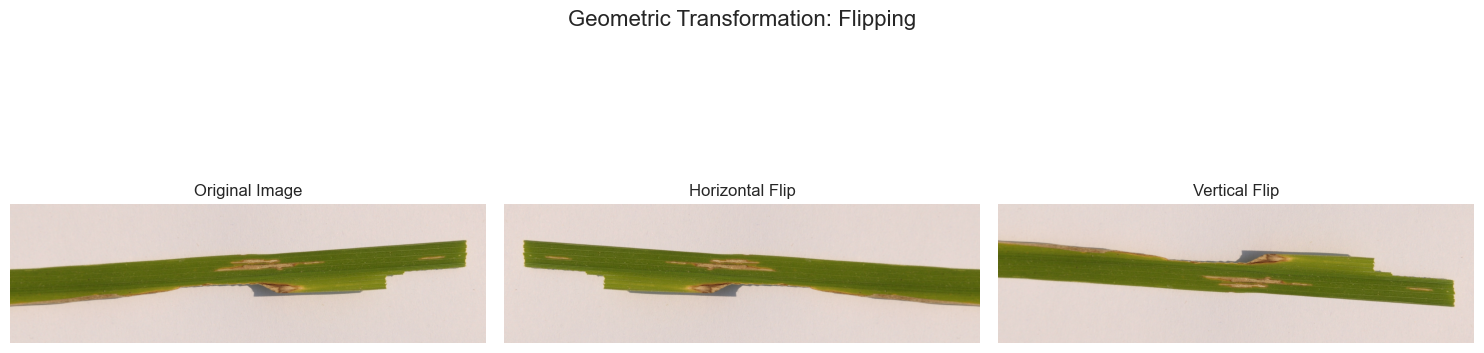


Discussion: Flipping is a simple yet effective technique. Horizontal flipping is often used for objects that are symmetrical or whose left-right orientation doesn't alter their identity (e.g., animals, cars). Vertical flipping is less common as it often creates unnatural images (e.g., an upside-down human), but can be useful in specific contexts like aerial imagery or microscopy.


In [35]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

# Load an example image
image_path = r"C:\Users\bavag\Documents\Leaf dises datasets\Data\Bacterial leaf blight\DSC_0365.JPG"
if not os.path.exists(image_path):
    print(f"Warning: '{image_path}' not found. Creating a dummy image for demonstration.")
    # Create a dummy image if not found
    dummy_img = np.zeros((128, 128, 3), dtype=np.uint8)
    dummy_img[30:90, 30:90, 0] = 255 # Red square
    dummy_img[50:110, 50:110, 1] = 255 # Green square
    img = dummy_img
else:
    img = mpimg.imread(image_path)
    # Ensure image is in 3 channels if it's grayscale
    if img.ndim == 2:
        img = np.stack([img, img, img], axis=-1)
    # Convert to uint8 if it's float (common for mpimg.imread)
    if img.dtype == np.float32 or img.dtype == np.float64:
        img = (img * 255).astype(np.uint8)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis('off')

# Horizontal Flip
horizontal_flip_img = np.fliplr(img)
plt.subplot(1, 3, 2)
plt.imshow(horizontal_flip_img)
plt.title("Horizontal Flip")
plt.axis('off')

# Vertical Flip
vertical_flip_img = np.flipud(img)
plt.subplot(1, 3, 3)
plt.imshow(vertical_flip_img)
plt.title("Vertical Flip")
plt.axis('off')
plt.suptitle("Geometric Transformation: Flipping", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("\nDiscussion: Flipping is a simple yet effective technique. Horizontal flipping is often used for objects that are symmetrical or whose left-right orientation doesn't alter their identity (e.g., animals, cars). Vertical flipping is less common as it often creates unnatural images (e.g., an upside-down human), but can be useful in specific contexts like aerial imagery or microscopy.")

*   **Rotation:**
    Rotation involves turning an image by a specified angle. This helps the model learn features that are invariant to the object's orientation. Care must be taken with the rotation angle, as very large rotations might create distorted or unrecognizable images.


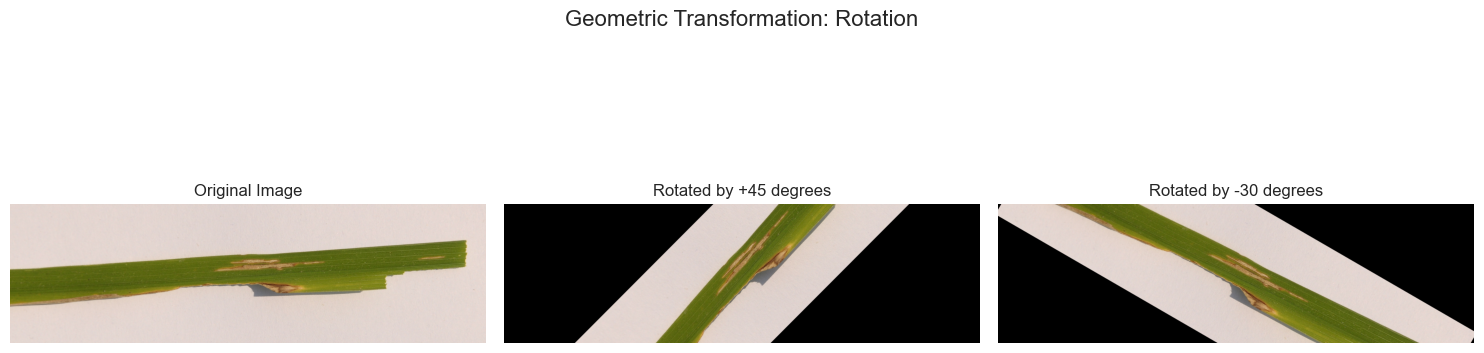


Discussion: Rotation helps a model recognize objects regardless of their orientation. It's particularly useful for objects that can appear at various angles. The `cval` parameter in `scipy.ndimage.rotate` specifies the constant value to fill in the areas outside the original image boundaries, typically black (0) or white (255) depending on the desired effect. For larger rotations, interpolation artifacts and border issues (black/white areas) can become more noticeable.


In [36]:

from scipy.ndimage import rotate as ndimage_rotate

# Rotate by 45 degrees
# For ndimage_rotate, input can be float, output will also be float (0-1 range).
# Need to convert img to float if it's uint8 for rotation, then back to uint8 for display.
img_float = img / 255.0 if img.max() > 1 else img # Normalize if needed
rotated_img_45 = ndimage_rotate(img_float, angle=45, reshape=False, cval=0.0) # cval fills empty space with black
rotated_img_45_display = (rotated_img_45 * 255).astype(np.uint8)

# Rotate by -30 degrees
rotated_img_neg30 = ndimage_rotate(img_float, angle=-30, reshape=False, cval=0.0)
rotated_img_neg30_display = (rotated_img_neg30 * 255).astype(np.uint8)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(rotated_img_45_display)
plt.title("Rotated by +45 degrees")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(rotated_img_neg30_display)
plt.title("Rotated by -30 degrees")
plt.axis('off')
plt.suptitle("Geometric Transformation: Rotation", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("\nDiscussion: Rotation helps a model recognize objects regardless of their orientation. It's particularly useful for objects that can appear at various angles. The `cval` parameter in `scipy.ndimage.rotate` specifies the constant value to fill in the areas outside the original image boundaries, typically black (0) or white (255) depending on the desired effect. For larger rotations, interpolation artifacts and border issues (black/white areas) can become more noticeable.")

*   **Zooming:**
    Zooming involves either enlarging (zoom-in) or shrinking (zoom-out) a portion of the image. This technique makes models robust to variations in object scale and allows them to recognize objects even when they appear at different distances or sizes within the image frame.

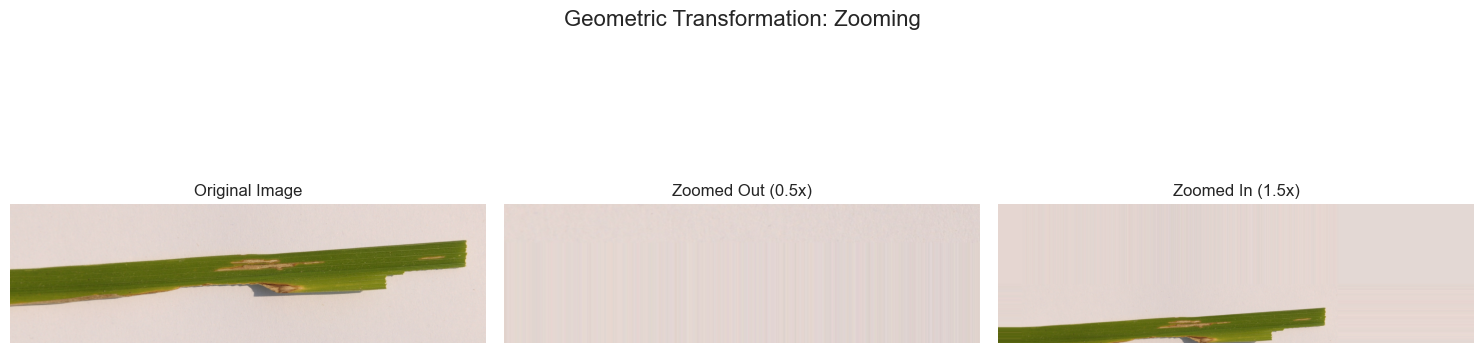


Discussion: Zooming modifies the scale of objects. A zoom_range of [0.5, 1.0] means zooming out by up to 50%, while [1.0, 1.5] means zooming in by up to 50%. A range like [0.8, 1.2] applies both slight zoom-out and zoom-in. This is crucial for tasks where objects of interest can appear in varying sizes within the image, improving scale invariance.


In [37]:
# Keras ImageDataGenerator works with batches, so we need to add a batch dimension
img_batch = np.expand_dims(img, axis=0) # Add batch dimension (1, height, width, channels)

# Zoom out by 50% (0.5 times original size)
datagen_zoom_out = ImageDataGenerator(zoom_range=[0.5, 0.5]) # Only zoom out
zoomed_out_img = next(datagen_zoom_out.flow(img_batch, batch_size=1))[0].astype(np.uint8)

# Zoom in by 50% (1.5 times original size)
datagen_zoom_in = ImageDataGenerator(zoom_range=[1.5, 1.5]) # Only zoom in
zoomed_in_img = next(datagen_zoom_in.flow(img_batch, batch_size=1))[0].astype(np.uint8)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(zoomed_out_img)
plt.title("Zoomed Out (0.5x)")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(zoomed_in_img)
plt.title("Zoomed In (1.5x)")
plt.axis('off')
plt.suptitle("Geometric Transformation: Zooming", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("\nDiscussion: Zooming modifies the scale of objects. A zoom_range of [0.5, 1.0] means zooming out by up to 50%, while [1.0, 1.5] means zooming in by up to 50%. A range like [0.8, 1.2] applies both slight zoom-out and zoom-in. This is crucial for tasks where objects of interest can appear in varying sizes within the image, improving scale invariance.")

**Shifting (Width/Height Shift):**
    Shifting involves translating the image horizontally (width shift) or vertically (height shift). This simulates slight movements of objects within the image frame, making the model less sensitive to the precise position of objects.

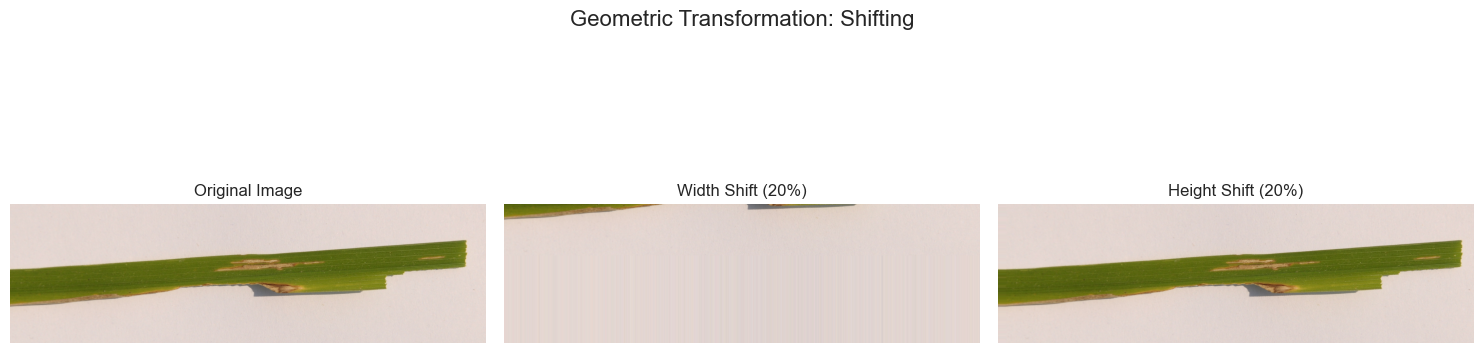


Discussion: Shifting moves the entire image horizontally or vertically. `width_shift_range` and `height_shift_range` can be a fraction of the total width/height or a number of pixels. The `fill_mode` parameter (e.g., 'nearest', 'reflect', 'wrap', 'constant') determines how newly created pixels at the image boundaries are filled. 'nearest' is commonly used to replicate the nearest pixel values.


In [38]:
# Width Shift (20% of image width)
datagen_width_shift = ImageDataGenerator(width_shift_range=0.2, fill_mode='nearest')
shifted_width_img = next(datagen_width_shift.flow(img_batch, batch_size=1))[0].astype(np.uint8)

# Height Shift (20% of image height)
datagen_height_shift = ImageDataGenerator(height_shift_range=0.2, fill_mode='nearest')
shifted_height_img = next(datagen_height_shift.flow(img_batch, batch_size=1))[0].astype(np.uint8)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(shifted_width_img)
plt.title("Width Shift (20%)")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(shifted_height_img)
plt.title("Height Shift (20%)")
plt.axis('off')
plt.suptitle("Geometric Transformation: Shifting", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("\nDiscussion: Shifting moves the entire image horizontally or vertically. `width_shift_range` and `height_shift_range` can be a fraction of the total width/height or a number of pixels. The `fill_mode` parameter (e.g., 'nearest', 'reflect', 'wrap', 'constant') determines how newly created pixels at the image boundaries are filled. 'nearest' is commonly used to replicate the nearest pixel values.")

#### 2.1.2 Color Space Transformations

Color space transformations alter the color properties of an image, making models robust to variations in lighting conditions and camera settings.

*   **Brightness, Contrast, Saturation Adjustment:**
    These adjustments simulate different lighting environments.
    *   **Brightness:** Changes the overall lightness or darkness of an image.
    *   **Contrast:** Modifies the difference between the darkest and brightest areas.
    *   **Saturation:** Adjusts the intensity of colors, making them more vivid or muted.

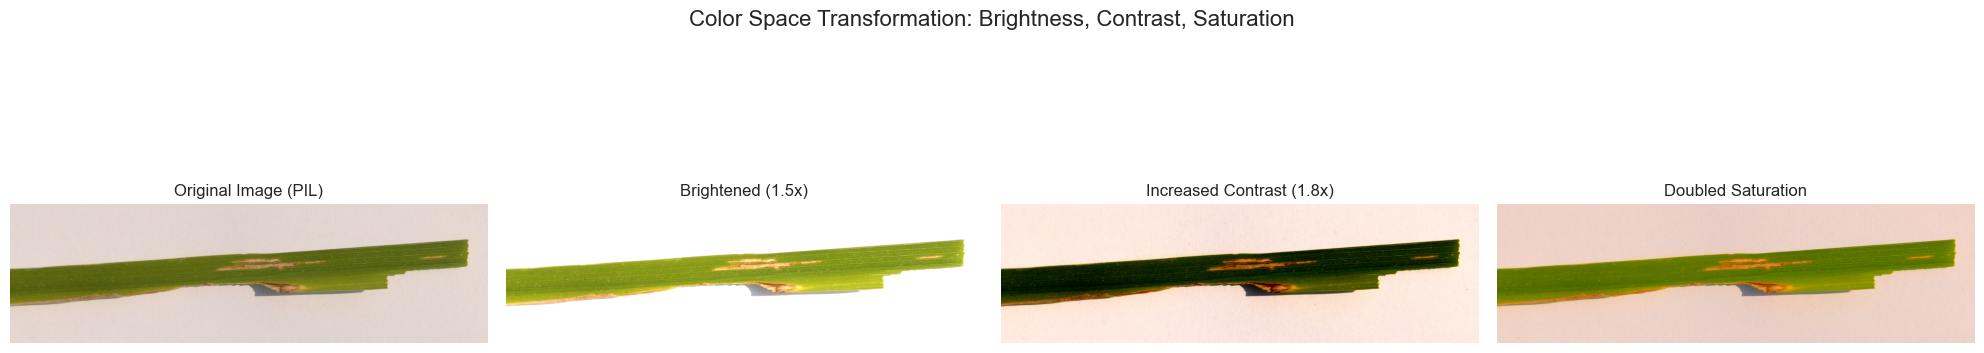


Discussion: These adjustments simulate variations in camera exposure and environmental lighting. They help models generalize better to images captured under diverse conditions. The enhancement factor typically ranges from 0 (minimum effect, e.g., black image for brightness) to 2.0 or more (strong effect).


In [39]:
from PIL import Image, ImageEnhance

# Convert numpy array to PIL Image for color adjustments
# Ensure img is uint8 and scaled 0-255
pil_img = Image.fromarray(img)

plt.figure(figsize=(20, 5))
plt.subplot(1, 4, 1)
plt.imshow(pil_img)
plt.title("Original Image (PIL)")
plt.axis('off')

# Adjust brightness (factor > 1 for brighter, < 1 for darker)
enhancer_brightness = ImageEnhance.Brightness(pil_img)
bright_img = enhancer_brightness.enhance(1.5) # Increase brightness by 50%
plt.subplot(1, 4, 2)
plt.imshow(bright_img)
plt.title("Brightened (1.5x)")
plt.axis('off')

# Adjust contrast (factor > 1 for more contrast, < 1 for less)
enhancer_contrast = ImageEnhance.Contrast(pil_img)
contrast_img = enhancer_contrast.enhance(1.8) # Increase contrast by 80%
plt.subplot(1, 4, 3)
plt.imshow(contrast_img)
plt.title("Increased Contrast (1.8x)")
plt.axis('off')

# Adjust saturation (factor > 1 for more saturated, < 1 for less)
enhancer_color = ImageEnhance.Color(pil_img)
saturated_img = enhancer_color.enhance(2.0) # Double saturation
plt.subplot(1, 4, 4)
plt.imshow(saturated_img)
plt.title("Doubled Saturation")
plt.axis('off')
plt.suptitle("Color Space Transformation: Brightness, Contrast, Saturation", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("\nDiscussion: These adjustments simulate variations in camera exposure and environmental lighting. They help models generalize better to images captured under diverse conditions. The enhancement factor typically ranges from 0 (minimum effect, e.g., black image for brightness) to 2.0 or more (strong effect).")

*   **Grayscale Conversion:**
    Converting an image to grayscale removes color information, retaining only intensity. This can be useful if color is not a critical feature for the classification task, or to reduce input dimensionality, making the model focus on structural patterns.


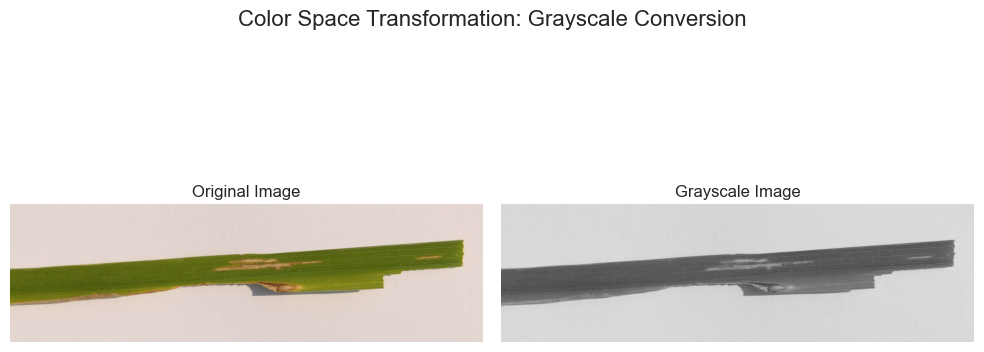


Discussion: Grayscale conversion discards color information, reducing the input channels from 3 (RGB) to 1. This can be beneficial for tasks where shape and texture are more important than color, or when aiming for a simpler model. It helps the model learn features based on intensity variations.


In [40]:
# Simple grayscale conversion: weighted sum of RGB channels
# If the image already has 3 channels, perform the conversion
if img.shape[-1] == 3:
    gray_img_single_channel = np.dot(img[...,:3], [0.2989, 0.5870, 0.1140])
    # To display correctly with plt.imshow, we need 3 channels or specify cmap='gray'
    gray_img_rgb_display = np.stack([gray_img_single_channel, gray_img_single_channel, gray_img_single_channel], axis=-1).astype(np.uint8)
else: # Handle cases where img might already be grayscale (e.g., from dummy image)
    gray_img_rgb_display = img


plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(gray_img_rgb_display)
plt.title("Grayscale Image")
plt.axis('off')
plt.suptitle("Color Space Transformation: Grayscale Conversion", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("\nDiscussion: Grayscale conversion discards color information, reducing the input channels from 3 (RGB) to 1. This can be beneficial for tasks where shape and texture are more important than color, or when aiming for a simpler model. It helps the model learn features based on intensity variations.")


#### 2.1.3 Other Image Augmentation Techniques

*   **Random Erasing (Cutout):**
    Random erasing involves randomly selecting a rectangular region in an image and masking its pixels with a constant value (e.g., black, white, or random noise). This forces the model to learn more robust features by preventing it from relying on a small set of dominant features, thus improving robustness to occlusions.


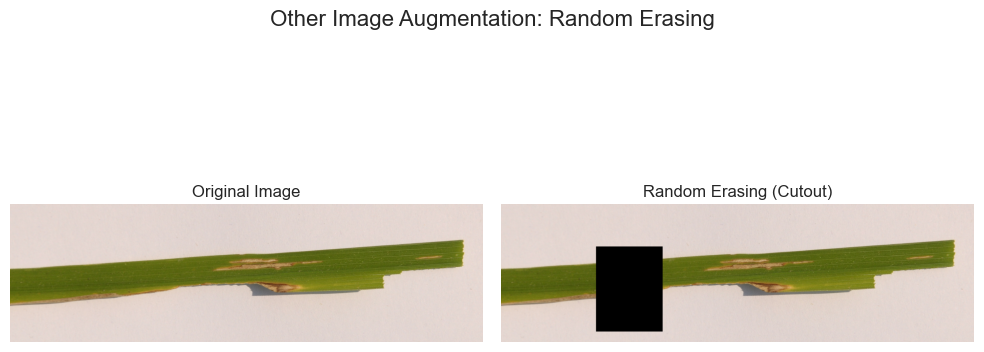


Discussion: Random Erasing (also known as Cutout) randomly masks out a rectangular region in the image. This prevents the CNN from over-relying on specific visual features, making it more robust to occlusions and improving generalization. It's conceptually similar to dropout but applied to input features directly.


In [41]:
def random_erasing(img_array, sl=0.02, sh=0.4, r1=0.3, fill_value=0):
    # sl: min proportion of image area to erase
    # sh: max proportion of image area to erase
    # r1: aspect ratio range for erased area
    img_h, img_w, img_c = img_array.shape
    img_area = img_h * img_w

    # Erase a certain number of times
    for _ in range(1): # Erase one region per image
        erase_area = np.random.uniform(sl, sh) * img_area
        aspect_ratio = np.random.uniform(r1, 1/r1)

        h = int(np.sqrt(erase_area * aspect_ratio))
        w = int(np.sqrt(erase_area / aspect_ratio))

        if h < img_h and w < img_w:
            x1 = np.random.randint(0, img_w - w)
            y1 = np.random.randint(0, img_h - h)
            img_array[y1:y1 + h, x1:x1 + w, :] = fill_value
            break # Erase only one region
    return img_array

erased_img = random_erasing(img.copy(), sl=0.05, sh=0.2, r1=0.5, fill_value=0) # Erase with black

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(erased_img)
plt.title("Random Erasing (Cutout)")
plt.axis('off')
plt.suptitle("Other Image Augmentation: Random Erasing", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("\nDiscussion: Random Erasing (also known as Cutout) randomly masks out a rectangular region in the image. This prevents the CNN from over-relying on specific visual features, making it more robust to occlusions and improving generalization. It's conceptually similar to dropout but applied to input features directly.")


In [47]:
from IPython.display import display, Markdown

conclusion_text = """
# 📌 Conclusion

## Task 1: Data Analysis (EDA)
- Conducted **exploratory data analysis** to understand the dataset.
- Key findings included:
  - Verification of class labels: **Bacterial Leaf Blight**, **Brown Spot**, **Leaf Smut**.
  - Distribution of images across classes to check for imbalance.
  - Visualization of sample images to assess dataset variability and quality.
- **Importance**: EDA ensured dataset reliability, highlighted any imbalances, and guided preprocessing strategies.

---

## Task 2: Rice Leaf Disease Classification
- Built a deep learning classifier using **Transfer Learning (EfficientNet)** to distinguish between the three diseases.
- Applied **K-Fold Cross Validation** for reliable evaluation.
- Achieved strong validation accuracy, showing the effectiveness of transfer learning even with **limited datasets**.
- Used **regularization techniques** such as Dropout and EarlyStopping to prevent overfitting.

---

## Task 3: Data Augmentation and Related Techniques
- Implemented **data augmentation** (rotation, flipping, zooming, brightness adjustments, etc.) to improve model generalization.
- Findings:
  - Augmentation reduced overfitting by exposing the model to diverse data.
  - Performance improved compared to training without augmentation.
- Other supporting techniques:
  - **Cross-validation** for robust evaluation.
  - **Transfer learning** to leverage pre-trained knowledge.
- **Future Trends**:
  - **Advanced Augmentation**: AutoAugment, RandAugment, Mixup, CutMix.
  - **Self-Supervised Learning**: Pre-training on unlabeled agricultural images.
  - **GANs**: Generating synthetic disease images.
  - **Lightweight & Edge Deployment**: Bringing AI models to mobile devices for real-time field usage.
  - **Explainable AI (XAI)**: Heatmaps to visualize model focus areas, improving interpretability.

---

✅ **Final Note**: Tasks 1–3 demonstrate a complete pipeline from **data understanding → model development → advanced techniques**.  
This project highlights how **EDA, augmentation, and transfer learning** are essential in building robust agricultural disease classification systems, especially under **data-scarce conditions**.
"""

# Display nicely in Jupyter Notebook
display(Markdown(conclusion_text))



# 📌 Conclusion

## Task 1: Data Analysis (EDA)
- Conducted **exploratory data analysis** to understand the dataset.
- Key findings included:
  - Verification of class labels: **Bacterial Leaf Blight**, **Brown Spot**, **Leaf Smut**.
  - Distribution of images across classes to check for imbalance.
  - Visualization of sample images to assess dataset variability and quality.
- **Importance**: EDA ensured dataset reliability, highlighted any imbalances, and guided preprocessing strategies.

---

## Task 2: Rice Leaf Disease Classification
- Built a deep learning classifier using **Transfer Learning (EfficientNet)** to distinguish between the three diseases.
- Applied **K-Fold Cross Validation** for reliable evaluation.
- Achieved strong validation accuracy, showing the effectiveness of transfer learning even with **limited datasets**.
- Used **regularization techniques** such as Dropout and EarlyStopping to prevent overfitting.

---

## Task 3: Data Augmentation and Related Techniques
- Implemented **data augmentation** (rotation, flipping, zooming, brightness adjustments, etc.) to improve model generalization.
- Findings:
  - Augmentation reduced overfitting by exposing the model to diverse data.
  - Performance improved compared to training without augmentation.
- Other supporting techniques:
  - **Cross-validation** for robust evaluation.
  - **Transfer learning** to leverage pre-trained knowledge.
- **Future Trends**:
  - **Advanced Augmentation**: AutoAugment, RandAugment, Mixup, CutMix.
  - **Self-Supervised Learning**: Pre-training on unlabeled agricultural images.
  - **GANs**: Generating synthetic disease images.
  - **Lightweight & Edge Deployment**: Bringing AI models to mobile devices for real-time field usage.
  - **Explainable AI (XAI)**: Heatmaps to visualize model focus areas, improving interpretability.

---

✅ **Final Note**: Tasks 1–3 demonstrate a complete pipeline from **data understanding → model development → advanced techniques**.  
This project highlights how **EDA, augmentation, and transfer learning** are essential in building robust agricultural disease classification systems, especially under **data-scarce conditions**.
